<h1><strong>Machine learning</strong></h1>

1. Supervised
2. Unsupervised

<h3>Supervised Machine Learning</h3>

In supervised learning, model is trained on a labeled dataset. This means for every input, you already know the correct ouptut. The model make prediction, compares it to the actual answer, and adjust its parameters until it gets it right.

<h3>Unsupervised Machine Learning</h3>

In unsupervised machine learning, the model is given unlabeled data, there is no direction given to the right answer. The algorithms job is to look at the data find underlying patterns, structures, or anomalies on its own.

<h1><strong>Linear Regression</strong></h1>

A regression problem where our goal is to predict a continuous , numeric value rather than a category or label.

$$
z = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n
$$

In [1]:
import numpy as np
import pandas as pd


In [2]:
x = np.array([1,2,3,4,5])
y = np.array([2,4,5,4,5])

In [3]:
x_mean = np.mean(x)
y_mean = np.mean(y)

In [4]:
numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sum((x-x_mean)**2)

In [5]:
m = numerator/denominator

In [6]:
m

np.float64(0.6)

In [7]:
c = y_mean - (m*x_mean)

In [8]:
c

np.float64(2.2)

In [9]:
y_pred = (m * x) + c

In [10]:
y_pred

array([2.8, 3.4, 4. , 4.6, 5.2])

In [11]:
y

array([2, 4, 5, 4, 5])

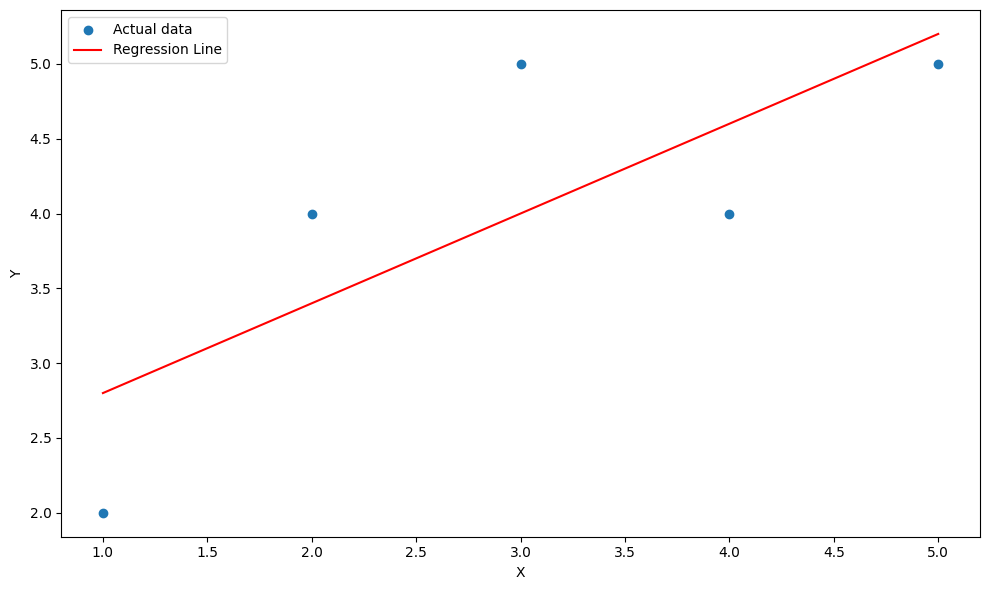

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(x,y,label="Actual data")
plt.plot(x,y_pred, label="Regression Line",c='red')

plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.legend()     
plt.show()

In [13]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.DataFrame({
    "hours":[1,2,3,4,5,6,7,8],
    "score":[10,20,30,40,50,60,70,80]}
)

In [14]:
X = df[['hours']]
y = df['score']

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
linear = LinearRegression()

model = linear.fit(X_train,y_train)

In [17]:
model.intercept_

np.float64(1.4210854715202004e-14)

In [18]:
model.coef_

array([10.])

In [19]:
y_pred = model.predict(X_test)

In [20]:
X_test

,hours
1,2
5,6


In [21]:
y_pred

array([20., 60.])

In [22]:
y_test

1    20
5    60
Name: score, dtype: int64

In [23]:
from sklearn.metrics import r2_score

r2_score(y_test,y_pred)

1.0

In [24]:
from sklearn.datasets import fetch_california_housing

In [25]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,columns=housing.feature_names
)

In [26]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [27]:
df['Price'] = housing.target

In [28]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [29]:
X = df.drop("Price",axis=1)

In [30]:
X.shape

(20640, 8)

In [31]:
y = df['Price']

In [32]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
X_test.shape

(4128, 8)

In [34]:
linear = LinearRegression()

model = linear.fit(X_train,y_train)

In [35]:
y_pred = model.predict(X_test)

In [36]:
r2_score(y_test,y_pred)

0.5757877060324508

In [37]:
model.intercept_

np.float64(-37.02327770606413)

In [38]:
model.coef_

array([ 4.48674910e-01,  9.72425752e-03, -1.23323343e-01,  7.83144907e-01,
       -2.02962058e-06, -3.52631849e-03, -4.19792487e-01, -4.33708065e-01])

Single feature -> Simple linear Regression<br>
Multiple features -> Multiple linear Regresion

<h2><strong>Evaluation Metrics</strong></h2>

- MAE (Mean Absolute Error)
- MSE (Mean Squared Error)
- RMSE (Root Mean Squared Error)
- R2_score 
- Adjusted R2_score


<h2>MAE (Mean absolute Error)</h2>

On average, how much wrong is the model

if MAE value is 0 -> Perfect model, Higher value -> worse model

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

<h2>MSE (Mean squared Error)</h2>

Large mistake get heavily punished

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

<h2>RMSE (Root mean Squared Error)</h2>

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

<h2>R2_score</h2>

- 1 -> Perfect prediction
- 0 -> Model no better than perfect
- <0 -> very bad model

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

<h2>Adjusted R2_Score</h2>



$$
Adjusted\ R^2 = 1 - \left(\frac{(1 - R^2)(n - 1)}{n - p - 1}\right)
$$

In [41]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

In [42]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MAE: ",mae)
print("MSE: ",mse)
print("RMSE: ",rmse)
print("R2_Score: ",r2)

MAE:  0.5332001304956548
MSE:  0.5558915986952444
RMSE:  0.7455813830127764
R2_Score:  0.5757877060324508


In [44]:
len(df.columns)

9

In [45]:
1 - ((1-r2)*(len(X_test))/(len(X_test)-len(df.columns)-1))

0.5747575644735203